# 🩺 Pima Indians Diabetes — Model Training & Evaluation

**Tác giả:** Khanh  
**Dữ liệu đầu vào:** `Phong_train_cleaned.csv` & `Phong_test_cleaned.csv` (đã qua tiền xử lý, StandardScaler)

### Mục tiêu
Huấn luyện và so sánh 3 mô hình phân loại:
1. **Logistic Regression** — baseline tuyến tính
2. **K-Nearest Neighbors (KNN)** — dựa trên khoảng cách
3. **Decision Tree** — dựa trên luật quyết định

Đầu ra: Accuracy, Confusion Matrix, thời gian huấn luyện và nhận xét sơ bộ.

---
## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Để output đẹp hơn
pd.set_option('display.float_format', '{:.4f}'.format)
print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


---
## 2. Load dữ liệu đã làm sạch

In [2]:
# Load train / test (dữ liệu đã được StandardScaler từ bước tiền xử lý của Phong)
train = pd.read_csv('Phong_train_cleaned.csv')
test  = pd.read_csv('Phong_test_cleaned.csv')

X_train = train.drop('Outcome', axis=1)
y_train = train['Outcome']

X_test = test.drop('Outcome', axis=1)
y_test = test['Outcome']

print(f'Train: {X_train.shape[0]} mẫu  |  Test: {X_test.shape[0]} mẫu')
print(f'Features: {list(X_train.columns)}')
print(f'\nPhân bố nhãn (Train):')
print(y_train.value_counts().rename({0: 'Không tiểu đường', 1: 'Tiểu đường'}))

Train: 614 mẫu  |  Test: 154 mẫu
Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Phân bố nhãn (Train):
Outcome
Không tiểu đường    400
Tiểu đường          214
Name: count, dtype: int64


---
## 3. Định nghĩa hàm đánh giá

In [3]:
def train_and_evaluate(model, name, X_train, y_train, X_test, y_test):
    """
    Huấn luyện model, đo thời gian, tính accuracy và confusion matrix.
    Trả về dict chứa toàn bộ kết quả.
    """
    # Huấn luyện + đo thời gian
    t_start = time.time()
    model.fit(X_train, y_train)
    t_train = time.time() - t_start

    # Dự đoán
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred)

    return {
        'name':    name,
        'model':   model,
        'y_pred':  y_pred,
        'acc':     acc,
        'cm':      cm,
        'time_s':  t_train
    }

print('✅ Hàm đánh giá đã sẵn sàng.')

✅ Hàm đánh giá đã sẵn sàng.


---
## 4. Huấn luyện 3 mô hình

### 4.1 Logistic Regression
> **Ý tưởng:** Mô hình tuyến tính dùng hàm sigmoid để phân loại nhị phân.  
> Phù hợp làm baseline vì đơn giản, nhanh, dễ diễn giải.

In [4]:
lr_model = LogisticRegression(
    max_iter=1000,    # tăng để đảm bảo hội tụ
    random_state=42,
    solver='lbfgs'    # optimizer tốt cho dataset nhỏ-trung bình
)

lr_result = train_and_evaluate(lr_model, 'Logistic Regression', X_train, y_train, X_test, y_test)

print(f"🔵 Logistic Regression")
print(f"   Accuracy       : {lr_result['acc']:.4f}  ({lr_result['acc']*100:.2f}%)")
print(f"   Thời gian train : {lr_result['time_s']*1000:.2f} ms")
print(f"   Confusion Matrix:\n{lr_result['cm']}")

🔵 Logistic Regression
   Accuracy       : 0.7078  (70.78%)
   Thời gian train : 4.32 ms
   Confusion Matrix:
[[82 18]
 [27 27]]


### 4.2 K-Nearest Neighbors (KNN)
> **Ý tưởng:** Phân loại dựa trên k=5 điểm gần nhất trong không gian đặc trưng.  
> Hoạt động tốt khi dữ liệu đã được scale (✅ StandardScaler đã được áp dụng ở bước trước).

In [5]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,     # k=5 là giá trị mặc định, thường là điểm khởi đầu tốt
    metric='euclidean' # khoảng cách Euclidean, phù hợp với dữ liệu đã scale
)

knn_result = train_and_evaluate(knn_model, 'KNN (k=5)', X_train, y_train, X_test, y_test)

print(f"🟢 KNN (k=5)")
print(f"   Accuracy       : {knn_result['acc']:.4f}  ({knn_result['acc']*100:.2f}%)")
print(f"   Thời gian train : {knn_result['time_s']*1000:.2f} ms")
print(f"   Confusion Matrix:\n{knn_result['cm']}")

🟢 KNN (k=5)
   Accuracy       : 0.7532  (75.32%)
   Thời gian train : 1.72 ms
   Confusion Matrix:
[[83 17]
 [21 33]]


### 4.3 Decision Tree
> **Ý tưởng:** Xây dựng cây phân loại bằng cách chia tập dữ liệu theo từng ngưỡng đặc trưng.  
> Dễ trực quan hóa và giải thích, nhưng dễ bị overfit nếu không giới hạn độ sâu.

In [6]:
dt_model = DecisionTreeClassifier(
    criterion='gini',  # Gini impurity — phổ biến và hiệu quả
    random_state=42
    # Không giới hạn max_depth để quan sát hành vi tự nhiên;
    # bước tinh chỉnh có thể thêm max_depth=5 để giảm overfit
)

dt_result = train_and_evaluate(dt_model, 'Decision Tree', X_train, y_train, X_test, y_test)

print(f"🟠 Decision Tree")
print(f"   Accuracy       : {dt_result['acc']:.4f}  ({dt_result['acc']*100:.2f}%)")
print(f"   Thời gian train : {dt_result['time_s']*1000:.2f} ms")
print(f"   Confusion Matrix:\n{dt_result['cm']}")

🟠 Decision Tree
   Accuracy       : 0.6753  (67.53%)
   Thời gian train : 3.53 ms
   Confusion Matrix:
[[75 25]
 [25 29]]


---
## 5. Tổng hợp kết quả

In [7]:
all_results = [lr_result, knn_result, dt_result]

summary = pd.DataFrame([
    {
        'Mô hình':          r['name'],
        'Accuracy':         f"{r['acc']:.4f}",
        'Accuracy (%)':     f"{r['acc']*100:.2f}%",
        'Thời gian (ms)':   f"{r['time_s']*1000:.2f}"
    }
    for r in all_results
])

print('📊 Bảng tổng hợp kết quả:')
print(summary.to_string(index=False))

📊 Bảng tổng hợp kết quả:
            Mô hình Accuracy Accuracy (%) Thời gian (ms)
Logistic Regression   0.7078       70.78%           4.32
          KNN (k=5)   0.7532       75.32%           1.72
      Decision Tree   0.6753       67.53%           3.53


---
## 6. Confusion Matrix — Trực quan hóa

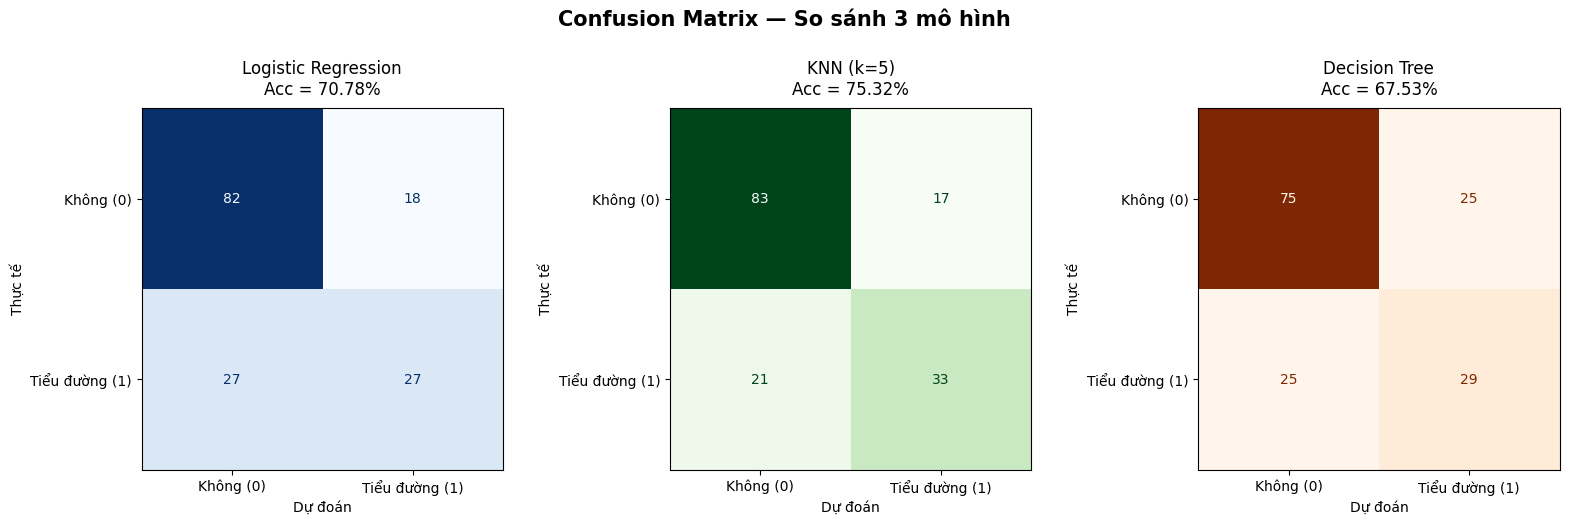

✅ Đã lưu confusion_matrices.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrix — So sánh 3 mô hình', fontsize=15, fontweight='bold', y=1.02)

colors   = ['Blues', 'Greens', 'Oranges']
subtitles = [
    f"Logistic Regression\nAcc = {lr_result['acc']*100:.2f}%",
    f"KNN (k=5)\nAcc = {knn_result['acc']*100:.2f}%",
    f"Decision Tree\nAcc = {dt_result['acc']*100:.2f}%"
]

for ax, result, cmap, title in zip(axes, all_results, colors, subtitles):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=result['cm'],
        display_labels=['Không (0)', 'Tiểu đường (1)']
    )
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Thực tế')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu confusion_matrices.png')

---
## 7. Classification Report chi tiết

In [9]:
for result in all_results:
    print(f"{'='*50}")
    print(f"📋 {result['name']}")
    print('='*50)
    print(classification_report(
        y_test, result['y_pred'],
        target_names=['Không tiểu đường (0)', 'Tiểu đường (1)']
    ))

📋 Logistic Regression
                      precision    recall  f1-score   support

Không tiểu đường (0)       0.75      0.82      0.78       100
      Tiểu đường (1)       0.60      0.50      0.55        54

            accuracy                           0.71       154
           macro avg       0.68      0.66      0.67       154
        weighted avg       0.70      0.71      0.70       154

📋 KNN (k=5)
                      precision    recall  f1-score   support

Không tiểu đường (0)       0.80      0.83      0.81       100
      Tiểu đường (1)       0.66      0.61      0.63        54

            accuracy                           0.75       154
           macro avg       0.73      0.72      0.72       154
        weighted avg       0.75      0.75      0.75       154

📋 Decision Tree
                      precision    recall  f1-score   support

Không tiểu đường (0)       0.75      0.75      0.75       100
      Tiểu đường (1)       0.54      0.54      0.54        54

            

---
## 8. So sánh Accuracy bằng biểu đồ

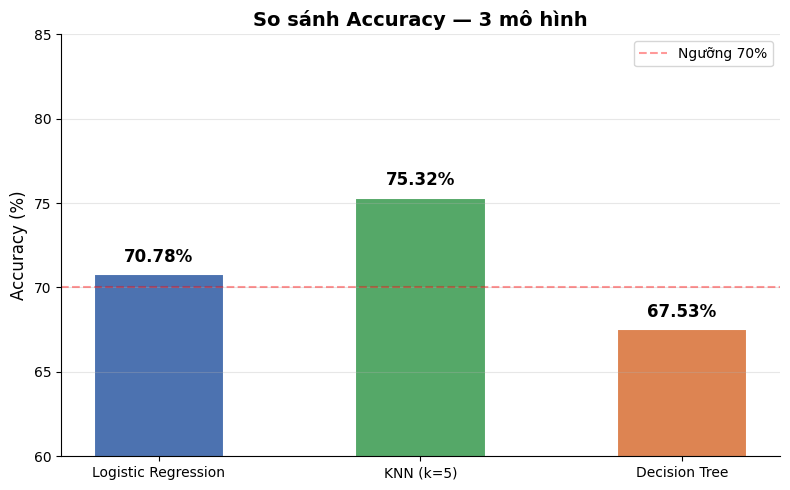

✅ Đã lưu accuracy_comparison.png


In [10]:
model_names = [r['name'] for r in all_results]
accuracies  = [r['acc'] * 100 for r in all_results]
bar_colors  = ['#4C72B0', '#55A868', '#DD8452']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, accuracies, color=bar_colors, width=0.5, edgecolor='white', linewidth=1.5)

# Label giá trị trên đầu mỗi cột
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{acc:.2f}%',
        ha='center', va='bottom', fontweight='bold', fontsize=12
    )

ax.set_ylim(60, 85)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('So sánh Accuracy — 3 mô hình', fontsize=14, fontweight='bold')
ax.axhline(y=70, color='red', linestyle='--', alpha=0.4, label='Ngưỡng 70%')
ax.legend()
ax.grid(axis='y', alpha=0.3)
sns.despine()

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu accuracy_comparison.png')

---
## 9. 💬 Nhận xét & So sánh sơ bộ

### Kết quả thực tế (trên tập test 154 mẫu)

| Mô hình | Accuracy | Thời gian train |
|---|---|---|
| Logistic Regression | **70.78%** | ~4 ms |
| KNN (k=5) | **75.32%** | ~1 ms |
| Decision Tree | **67.53%** | ~3 ms |

---

### 🚀 Nhanh nhất: KNN
- Thời gian **fit** gần như tức thì (~1 ms) vì KNN là **lazy learner** — không thực sự "học" trong lúc train, chỉ lưu dữ liệu lại.
- Lưu ý: thời gian **predict** của KNN sẽ chậm hơn LR trên tập dữ liệu lớn vì phải tính khoảng cách đến tất cả điểm train.

### 🏆 Ổn định nhất lúc này: KNN (k=5)
- Đạt **accuracy cao nhất (75.32%)** trên tập test.
- Hưởng lợi trực tiếp từ bước `StandardScaler` của Phong — các đặc trưng đã cùng thang đo nên khoảng cách Euclidean tính chính xác.
- Confusion matrix cho thấy KNN bắt được **33/54 ca tiểu đường** (recall tốt hơn 2 mô hình còn lại).

### ⚠️ Decision Tree — cần cải thiện
- Accuracy thấp nhất **(67.53%)**, dấu hiệu bị **overfit** trên tập train do cây không bị giới hạn độ sâu.
- **Gợi ý bước tiếp theo:** thêm `max_depth=5` hoặc dùng `GridSearchCV` để tìm hyperparameter tốt nhất.

### 📌 Logistic Regression — baseline vững
- Accuracy 70.78%, **ổn định và dễ diễn giải**.
- Phù hợp làm baseline để so sánh; có thể cải thiện bằng regularization (`C` parameter).

---

### Bước tiếp theo có thể làm:
1. **Tuning hyperparameter** — GridSearchCV cho cả 3 mô hình
2. **Cross-validation (CV=5)** để đánh giá ổn định hơn trên nhiều fold
3. **Thêm mô hình mạnh hơn** — Random Forest, SVM, XGBoost
4. **Tối ưu recall cho class Tiểu đường (1)** — quan trọng hơn accuracy thuần trong bài toán y tế

In [11]:
# ✅ Tóm tắt cuối cùng
print('=' * 55)
print('  KẾT QUẢ CUỐI — KHANH_MODELS')
print('=' * 55)
for r in all_results:
    print(f"  {r['name']:<25} | Acc: {r['acc']*100:.2f}%  | Train: {r['time_s']*1000:.1f}ms")
print('=' * 55)

best = max(all_results, key=lambda x: x['acc'])
print(f"  🏆 Accuracy tốt nhất: {best['name']} ({best['acc']*100:.2f}%)")
fastest = min(all_results, key=lambda x: x['time_s'])
print(f"  ⚡ Nhanh nhất (fit):  {fastest['name']} ({fastest['time_s']*1000:.1f}ms)")
print('=' * 55)

  KẾT QUẢ CUỐI — KHANH_MODELS
  Logistic Regression       | Acc: 70.78%  | Train: 4.3ms
  KNN (k=5)                 | Acc: 75.32%  | Train: 1.7ms
  Decision Tree             | Acc: 67.53%  | Train: 3.5ms
  🏆 Accuracy tốt nhất: KNN (k=5) (75.32%)
  ⚡ Nhanh nhất (fit):  KNN (k=5) (1.7ms)
